In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/Automobile_data.csv")

In [3]:
df.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,13495
1,3,?,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,16500
2,1,?,alfa-romero,gas,hatchback,rwd,front,65.5,52.4,ohcv,152,154,19,26,16500
3,2,164,audi,gas,sedan,fwd,front,66.2,54.3,ohc,109,102,24,30,13950
4,2,164,audi,gas,sedan,4wd,front,66.4,54.3,ohc,136,115,18,22,17450


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   body-style         205 non-null    object 
 5   drive-wheels       205 non-null    object 
 6   engine-location    205 non-null    object 
 7   width              205 non-null    float64
 8   height             205 non-null    float64
 9   engine-type        205 non-null    object 
 10  engine-size        205 non-null    int64  
 11  horsepower         205 non-null    object 
 12  city-mpg           205 non-null    int64  
 13  highway-mpg        205 non-null    int64  
 14  price              205 non-null    int64  
dtypes: float64(2), int64(5), object(8)
memory usage: 24.2+ KB


In [5]:
df.describe()

,symboling,width,height,engine-size,city-mpg,highway-mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,65.907805,53.724878,126.907317,25.219512,30.751220,13227.478049
std,1.245307,2.145204,2.443522,41.642693,6.542142,6.886443,7902.651615
min,-2.000000,60.300000,47.800000,61.000000,13.000000,16.000000,5118.000000
25%,0.000000,64.100000,52.000000,97.000000,19.000000,25.000000,7788.000000
50%,1.000000,65.500000,54.100000,120.000000,24.000000,30.000000,10345.000000
75%,2.000000,66.900000,55.500000,141.000000,30.000000,34.000000,16500.000000
max,3.000000,72.300000,59.800000,326.000000,49.000000,54.000000,45400.000000


<Axes: >

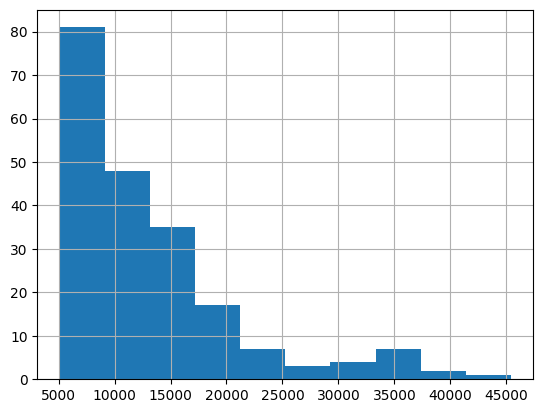

In [6]:
df['price'].hist()

<Axes: >

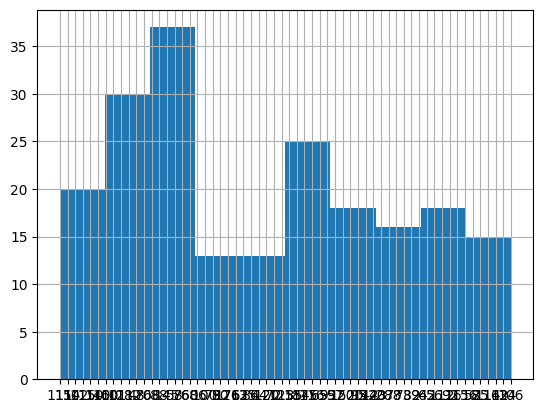

In [7]:
df['horsepower'].hist()

<Axes: >

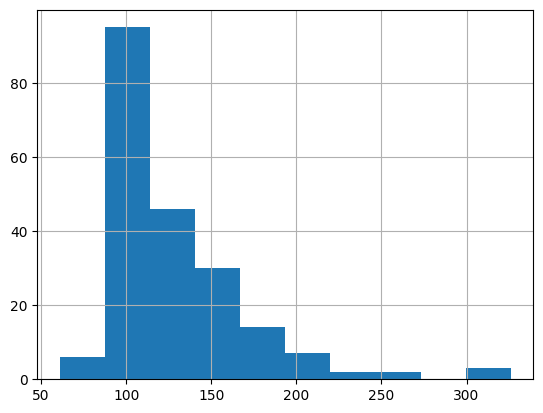

In [8]:
df['engine-size'].hist()

<Axes: >

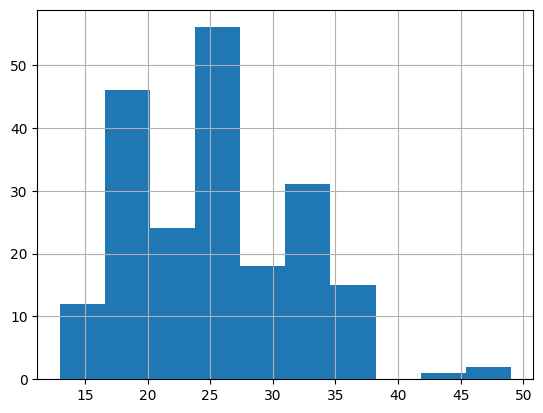

In [9]:
df['city-mpg'].hist()

In [10]:
df.replace("?", np.nan, inplace=True)

In [11]:
df["normalized-losses"] = pd.to_numeric(
    df["normalized-losses"],
    errors="coerce"
)

df["horsepower"] = pd.to_numeric(
    df["horsepower"],
    errors="coerce"
)

In [12]:
df.isnull().sum()

,0
symboling,0
normalized-losses,41
make,0
fuel-type,0
body-style,0
drive-wheels,0
engine-location,0
width,0
height,0
engine-type,0


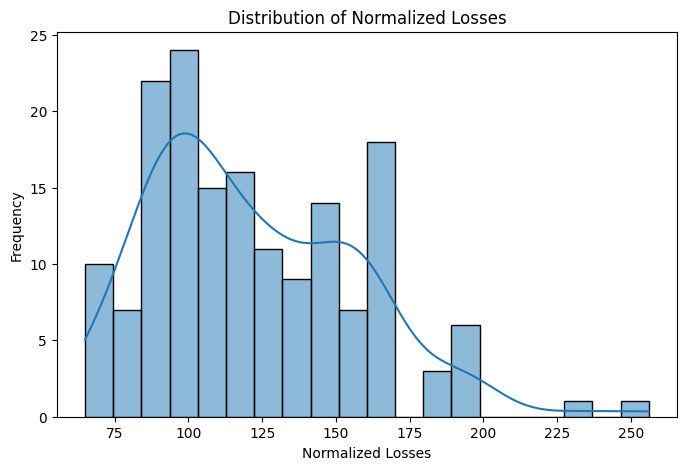

Skewness of Normalized Losses: 0.766


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='normalized-losses',
    bins=20,
    kde=True
)

plt.title('Distribution of Normalized Losses')
plt.xlabel('Normalized Losses')
plt.ylabel('Frequency')

plt.show()

# Skewness Value
print("Skewness of Normalized Losses:",
      round(df['normalized-losses'].skew(), 3))

In [14]:
df['normalized-losses'].fillna(
    df['normalized-losses'].median(),
    inplace=True
)

/tmp/ipykernel_3451/390440073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['normalized-losses'].fillna(


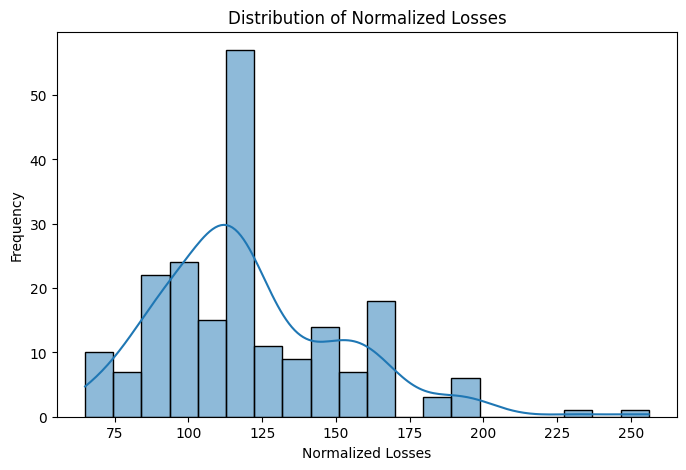

Skewness of Normalized Losses: 0.976


In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='normalized-losses',
    bins=20,
    kde=True
)

plt.title('Distribution of Normalized Losses')
plt.xlabel('Normalized Losses')
plt.ylabel('Frequency')

plt.show()

# Skewness Value
print("Skewness of Normalized Losses:",
      round(df['normalized-losses'].skew(), 3))

In [16]:
df['horsepower'].fillna(
    df['horsepower'].median(),
    inplace=True
)

/tmp/ipykernel_3451/2085030141.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(


In [17]:
df.isnull().sum()

,0
symboling,0
normalized-losses,0
make,0
fuel-type,0
body-style,0
drive-wheels,0
engine-location,0
width,0
height,0
engine-type,0


In [18]:
df.duplicated().sum()

np.int64(0)

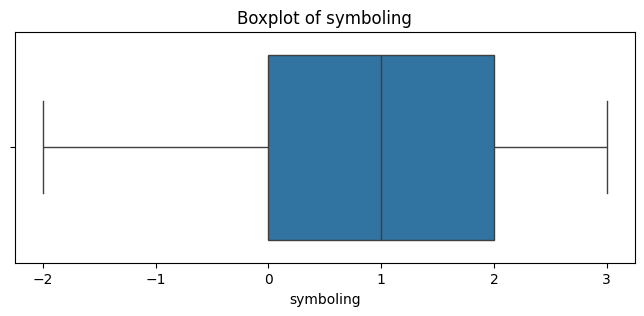

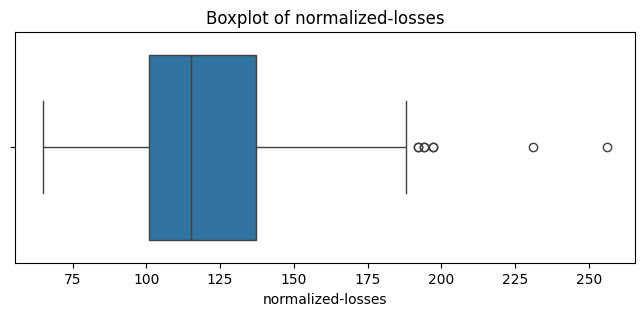

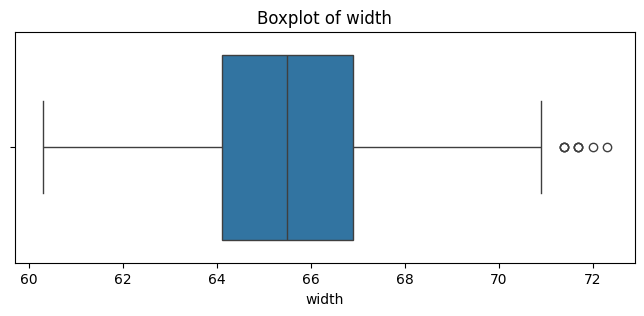

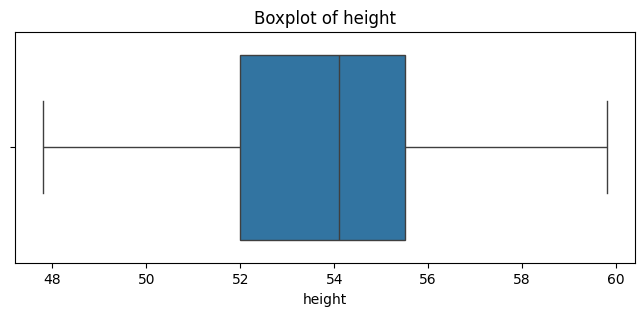

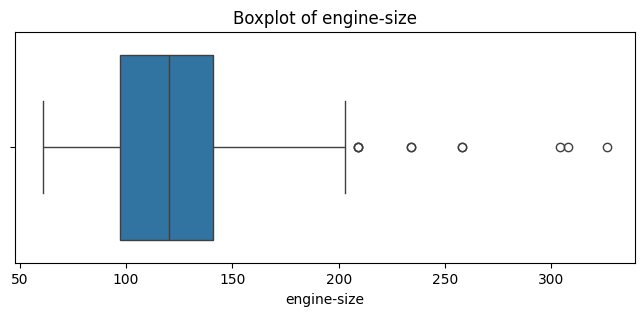

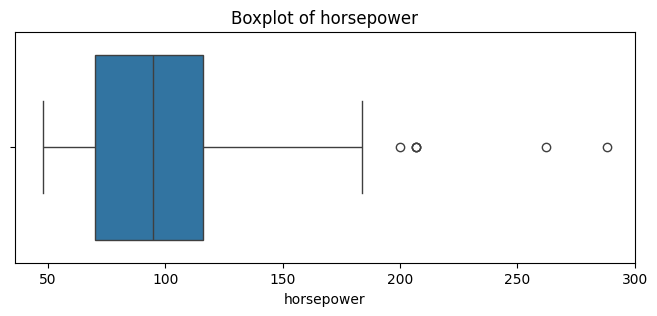

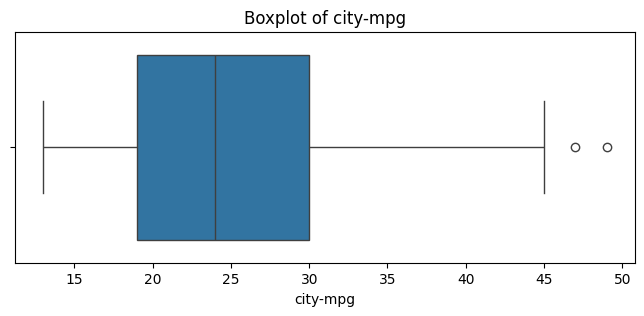

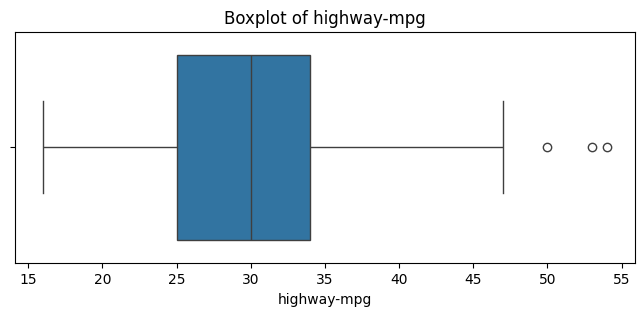

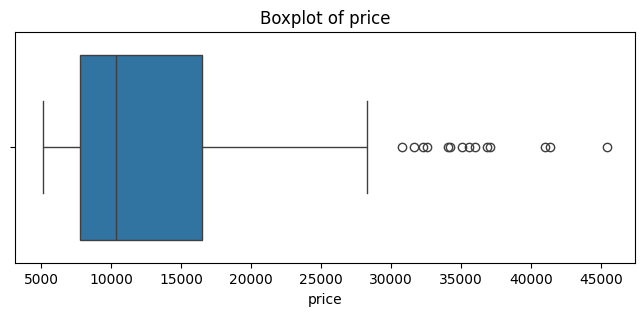

In [19]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:

    plt.figure(figsize=(8, 3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

In [20]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (169, 15)


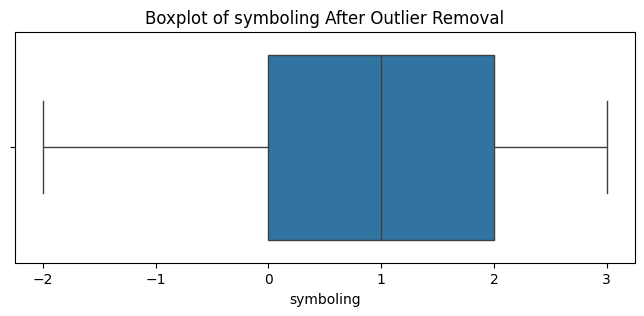

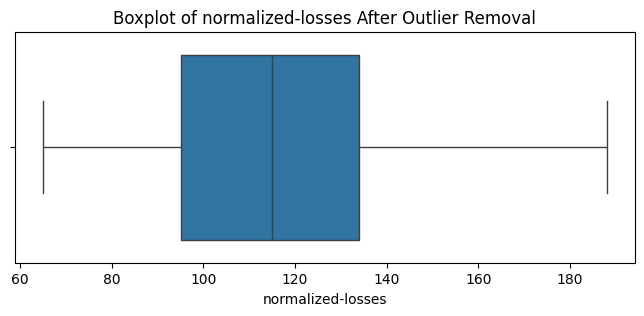

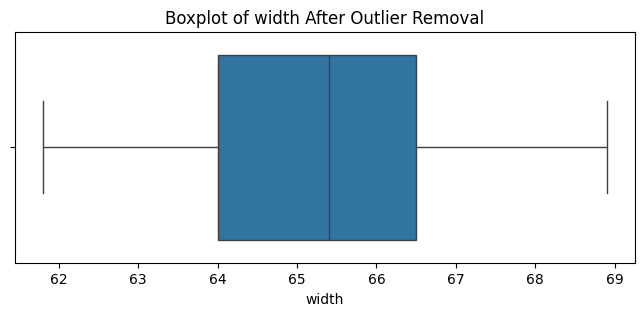

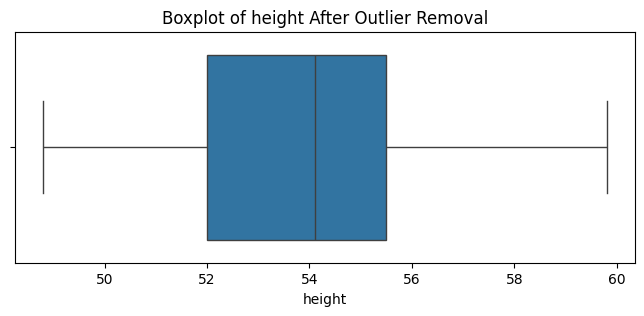

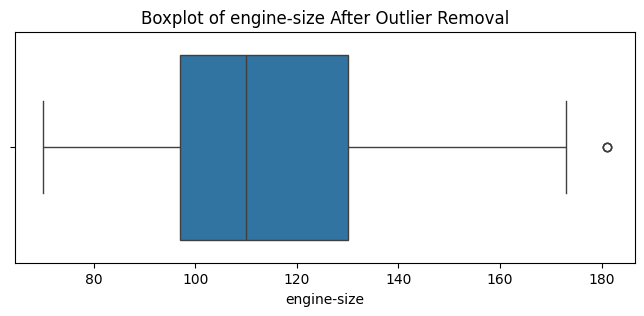

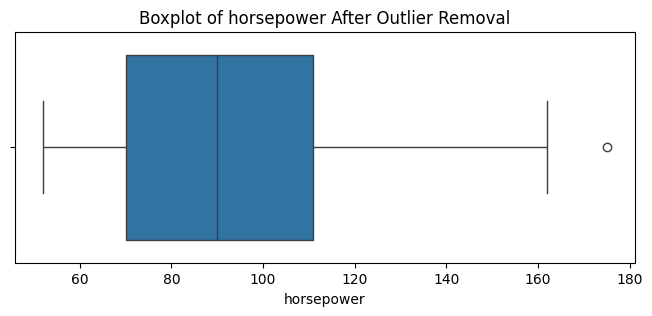

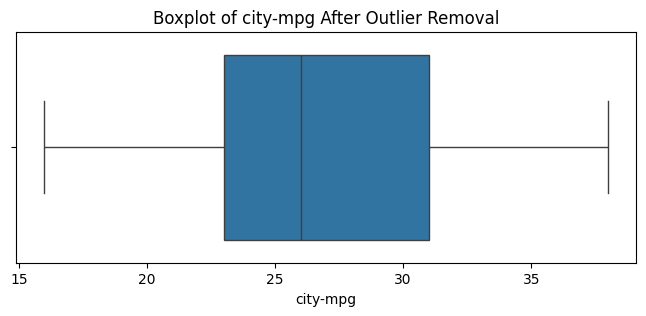

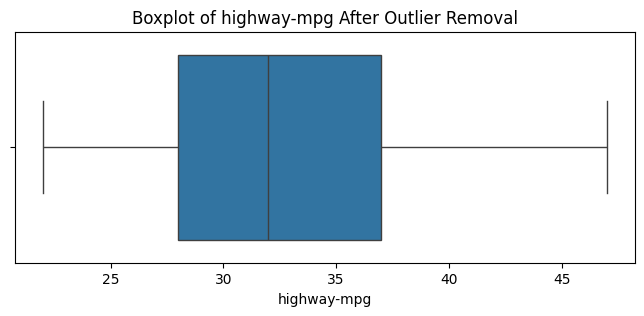

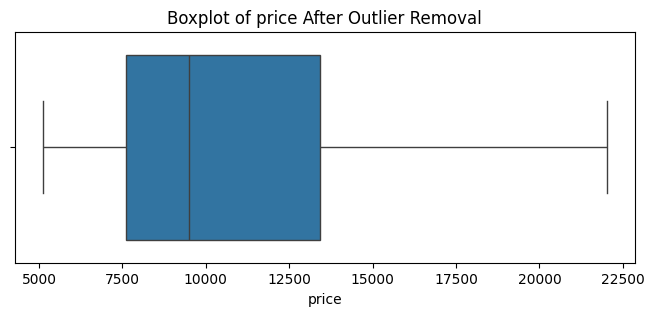

In [21]:
for col in num_cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col} After Outlier Removal')

    plt.show()

In [22]:
df_num=df.select_dtypes(["int64","float64"])
df_cat=df.select_dtypes(object)

In [23]:
df_cat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169 entries, 0 to 202
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   make             169 non-null    object
 1   fuel-type        169 non-null    object
 2   body-style       169 non-null    object
 3   drive-wheels     169 non-null    object
 4   engine-location  169 non-null    object
 5   engine-type      169 non-null    object
dtypes: object(6)
memory usage: 9.2+ KB


In [24]:
from sklearn.preprocessing import LabelEncoder
for col in df_cat :
    le=LabelEncoder() #create the object of LabelEncoder class
    df_cat[col]=le.fit_transform(df_cat[col])